In [29]:
%load_ext autoreload
%autoreload 2
print('Autoreload enabled. Notebook will now automatically detect changes to .py files!')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Autoreload enabled. Notebook will now automatically detect changes to .py files!


In [30]:
import os, sys
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath('..'))

import torch
print(f'PyTorch: {torch.__version__} | Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.11.0+cpu | Device: CPU


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print('All imports OK')

All imports OK


In [32]:
from src.data_pipeline.preprocess import load_hm_data, build_user_profiles

articles, transactions = load_hm_data()
user_profiles = build_user_profiles(transactions, articles)

print(f'Articles: {articles.shape} | Transactions: {transactions.shape} | User Profiles: {user_profiles.shape}')
display(articles[['article_id', 'prod_name', 'product_group_name', 'purchase_count']].head(3))

[H&M] Articles: (105542, 27) | Transactions: (1000000, 7)
[Profiles] Built 214,936 user profiles.
Articles: (105542, 27) | Transactions: (1000000, 7) | User Profiles: (214936, 5)


,article_id,prod_name,product_group_name,purchase_count
0,108775015,Strap top,Garment Upper body,1123
1,108775044,Strap top,Garment Upper body,477
2,108775051,Strap top (1),Garment Upper body,125


In [33]:
from src.data_pipeline.create_embeddings import get_embedding_model, generate_hm_embeddings

embedding_model = get_embedding_model()
catalog_embeddings, catalog = generate_hm_embeddings(articles, embedding_model, top_n=10000)

print(f'Embedding matrix shape: {catalog_embeddings.shape}')

[Embeddings] Loading model: all-MiniLM-L6-v2
[Embeddings] Loading cached H&M embeddings...
Embedding matrix shape: (10000, 384)


In [34]:
from src.retrieval.vec_store import get_vector_store
from src.data_pipeline.create_embeddings import generate_query_embedding

vector_store = get_vector_store(catalog_embeddings, catalog)

USER_QUERY = 'I need a warm waterproof jacket for winter hiking'
query_vec = generate_query_embedding(USER_QUERY, embedding_model)

candidates = vector_store.search(query_vec, top_k=5000)

print(f"Query: '{USER_QUERY}'")
print(f'Top 5 semantic matches:')
display(candidates[['article_id', 'prod_name', 'purchase_count', 'semantic_score']].head(5))

Query: 'I need a warm waterproof jacket for winter hiking'
Top 5 semantic matches:


,article_id,prod_name,purchase_count,semantic_score
0,560270001,NORWAY fleece jacket,274,0.591386
1,560270014,NORWAY fleece jacket,39,0.591386
2,560270003,NORWAY fleece jacket,75,0.591386
3,560270002,NORWAY fleece jacket,151,0.591386
4,560270009,NORWAY fleece jacket (1),142,0.588204


In [35]:
from src.ranking.feature_eng import build_ranking_features
from src.ranking.train_ranker import get_rlhf_rewards

rewards = get_rlhf_rewards()
candidates['article_id'] = candidates['article_id'].astype(str)
rewards['article_id'] = rewards['article_id'].astype(str)
candidates = candidates.merge(rewards, on='article_id', how='left')
candidates['rlhf_reward'] = candidates['rlhf_reward'].fillna(0.0)

user_profile = user_profiles.iloc[0]
context = {'season': 'winter'}

featured_candidates, FEATURE_COLS = build_ranking_features(candidates, user_profile, context)
print('Feature columns:', FEATURE_COLS)
display(featured_candidates[FEATURE_COLS].head(3))

Feature columns: ['semantic_score', 'normalized_popularity', 'user_total_purchases', 'user_avg_price', 'season_match', 'desc_length', 'rlhf_reward']


,semantic_score,normalized_popularity,user_total_purchases,user_avg_price,season_match,desc_length,rlhf_reward
0,0.591386,0.122049,8,0.036424,0,24,99.0
1,0.591386,0.017372,8,0.036424,0,24,0.0
2,0.591386,0.033408,8,0.036424,0,24,0.0


In [36]:
from src.ranking.train_ranker import build_training_data, train_ranker

X, y = build_training_data(featured_candidates, FEATURE_COLS, transactions)

print(f'Training samples: {X.shape[0]} | Positive labels: {y.sum()} | Ratio: {y.mean():.2%}')
ranker = train_ranker(X, y)

Training samples: 5000 | Positive labels: 2473 | Ratio: 49.46%
[Ranker] Validation AUC: 0.6069
[Ranker] Model saved to c:\Users\siddh\OneDrive\Desktop\n\recom\src\ranking\..\..\data\processed\ranker_lgb.pkl


--- Model Evaluation Metrics (on notebook sample) ---
Accuracy:  0.6204
Precision: 0.6268
Recall:    0.5746
F1 Score:  0.5996
AUC:       0.6808


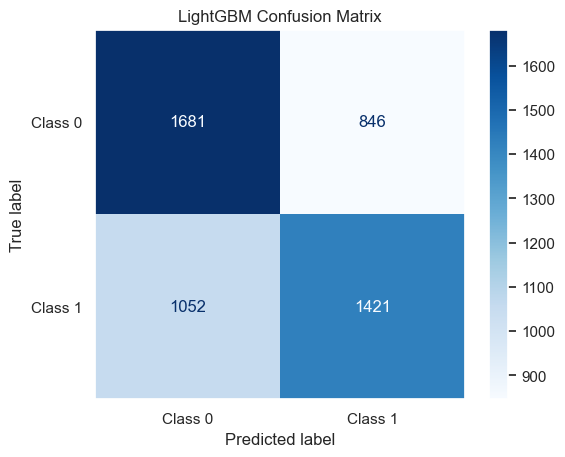

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds_prob = ranker.predict(X)
preds_binary = (preds_prob >= 0.5).astype(int)

if len(set(y.tolist())) > 1:
    acc = accuracy_score(y, preds_binary)
    prec = precision_score(y, preds_binary, zero_division=0)
    rec = recall_score(y, preds_binary, zero_division=0)
    f1 = f1_score(y, preds_binary, zero_division=0)
    auc = roc_auc_score(y, preds_prob)
    
    print("--- Model Evaluation Metrics (on notebook sample) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y, preds_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('LightGBM Confusion Matrix')
    plt.grid(False)
    plt.show()
else:
    print("Standard metrics cannot be fully calculated: The sample data only contains a single class.")
    print(f"\nCurrent raw accuracy: {accuracy_score(y, preds_binary):.4f}")


In [38]:
import importlib
import src.ranking.train_ranker
importlib.reload(src.ranking.train_ranker)
from src.ranking.train_ranker import rank_candidates

final_ranked = rank_candidates(featured_candidates, FEATURE_COLS, ranker)
print('Final ranked recommendations (Top 5):')
display(final_ranked[['article_id', 'prod_name', 'semantic_score', 'normalized_popularity', 'rank_score']].head(5))


Final ranked recommendations (Top 5):


,article_id,prod_name,semantic_score,normalized_popularity,rank_score
0,630116001,SUPREME TIGHTS,0.236762,0.226281,0.694381
1,630116006,SUPREME TIGHTS,0.236762,0.113140,0.694381
2,630116011,SUPREME TIGHTS,0.236762,0.084633,0.694381
3,630116007,SUPREME TIGHTS,0.236762,0.039198,0.694381
4,630116004,SUPREME TIGHTS,0.236762,0.236971,0.694381


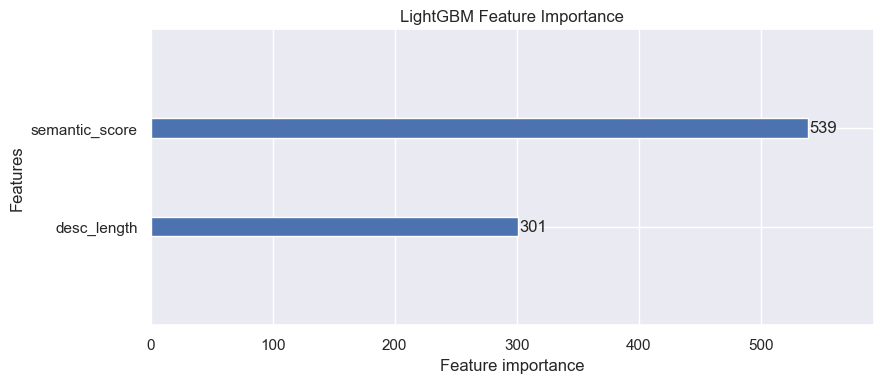

In [39]:
try:
    importance = ranker.feature_importance()
    if importance.sum() > 0:
        lgb.plot_importance(ranker, max_num_features=7, figsize=(9, 4), title='LightGBM Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print('Feature importance plot skipped: model trained on single-class labels (all candidates relevant).')
        print('This is expected when all retrieved items are in the transaction history.')
        fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importance})
        display(fi_df)
except Exception as e:
    print(f'Feature importance plot skipped: {e}')

In [40]:
from src.reasoning.llm_agent import build_explanation_chain, explain_recommendation

chain, mode = build_explanation_chain()
top_item = final_ranked.iloc[0]

explanation = explain_recommendation(
    query=USER_QUERY,
    item_name=str(top_item['prod_name']),
    item_desc=str(top_item.get('detail_desc', ''))[:300],
    season='winter',
    chain=chain,
    mode=mode,
)

print(f'Top Recommendation: {top_item["prod_name"]}')
print(f'\nExplanation:\n{explanation}')

Top Recommendation: SUPREME TIGHTS

Explanation:
We recommend 'SUPREME TIGHTS' because it closely matches your request for 'I need a warm waterproof jacket for winter hiking' and is a popular choice among customers with similar preferences.


In [41]:
from src.ranking.train_ranker import log_feedback, get_rlhf_rewards

log_feedback(str(top_item['article_id']), 'click')    # +1
log_feedback(str(top_item['article_id']), 'cart')     # +3
log_feedback(str(top_item['article_id']), 'purchase') # +5

rewards_df = get_rlhf_rewards()
print('Accumulated RLHF Rewards:')
display(rewards_df.head())

Accumulated RLHF Rewards:


,article_id,rlhf_reward
0,560270001,99
1,630116001,9


In [42]:
from sklearn.metrics import roc_auc_score

y_true = y.reset_index(drop=True)
y_score = ranker.predict(X.fillna(0))

def precision_at_k(y_true, y_score, k=10):
    top_k_idx = np.argsort(y_score)[::-1][:k]
    return y_true.iloc[top_k_idx].mean()

def recall_at_k(y_true, y_score, k=10):
    top_k_idx = np.argsort(y_score)[::-1][:k]
    return y_true.iloc[top_k_idx].sum() / max(y_true.sum(), 1)

print('Evaluation Results:')
results = []
for k in [5, 10, 20]:
    p = precision_at_k(y_true, y_score, k)
    r = recall_at_k(y_true, y_score, k)
    results.append({'K': k, 'Precision@K': round(p, 4), 'Recall@K': round(r, 4)})
display(pd.DataFrame(results))

if len(set(y_true.tolist())) > 1:
    print(f'ROC-AUC: {roc_auc_score(y_true, y_score):.4f}')
else:
    print('ROC-AUC: N/A (all labels are the same class in this query sample)')



Evaluation Results:


,K,Precision@K,Recall@K
0,5,1.00,0.0020
1,10,1.00,0.0040
2,20,0.95,0.0077


ROC-AUC: 0.6808
